## TP - Séance 1 : Fondations du Real-Time Data Engineering (données, événements, flux, temporalité et introduction à Apache Kafka)
**Professeur : Dr. Khalil HADDAOUI**

Nous allons :

1. Simuler des **flux d’événements** (clics, transactions…)
2. Comparer une vision **batch** vs une vision **streaming naïve**
3. Visualiser le **désordre** entre Event Time et Processing Time
4. Manipuler Event / Ingestion / Processing Time
5. Construire un mini modèle de **log Kafka** en Python
6. Illustrer les **garanties de livraison** (at-most-once, at-least-once, exactly-once “approché”)
7. Terminer par **3 mini-projets guidés**.


Chaque bloc code est commenté.  
Les cellules `TO DO` sont à compléter par vous.


In [1]:
#Imports de base

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random

plt.style.use("seaborn-v0_8-whitegrid")

# Pour que les résultats soient reproductibles
np.random.seed(42)
random.seed(42)


## 1. Simulation d'un flux d'événements web

On simule un petit site web avec :

- des utilisateurs `user_id` (1, 2, 3, …)
- différents types d’événements : `page_view`, `click`, `checkout`
- un **Event Time** (moment métier) et un **Processing Time** (moment de traitement)

Objectif :

- créer un `DataFrame` d’événements
- voir à quoi ressemble un **flux** par rapport à une simple table "statique".


In [2]:
#Simulation d'un flux d'événements

def simulate_web_events(
    n_events=500,
    start_time=datetime(2025, 1, 1, 12, 0, 0),
    max_seconds=3600
):
    """
    Simule un flux d'événements web.
    
    - n_events : nombre total d'événements
    - start_time : point de départ de la timeline (Event Time)
    - max_seconds : horizon temporel maximum (en secondes) pour les Event Time
    
    Chaque événement contient :
    - event_id : identifiant unique
    - user_id : identifiant utilisateur
    - event_type : page_view / click / checkout
    - event_time : datetime du point de vue métier
    """
    events = []
    
    for event_id in range(n_events):
        # Choix d'un utilisateur
        user_id = np.random.randint(1, 21)  # 20 utilisateurs
        
        # Choix du type d'événement (probabilités arbitraires)
        event_type = np.random.choice(
            ["page_view", "click", "checkout"],
            p=[0.7, 0.25, 0.05]
        )
        
        # Event Time : on prend un offset aléatoire en secondes depuis start_time
        offset_seconds = np.random.randint(0, max_seconds)
        event_time = start_time + timedelta(seconds=int(offset_seconds))
        
        events.append(
            {
                "event_id": event_id,
                "user_id": user_id,
                "event_type": event_type,
                "event_time": event_time,
            }
        )
    
    df = pd.DataFrame(events)
    # On ordonne par Event Time (ordre "réel" métier)
    df = df.sort_values("event_time").reset_index(drop=True)
    return df

df_events = simulate_web_events()
df_events.head(10)


,event_id,user_id,event_type,event_time
0,438,13,page_view,2025-01-01 12:00:15
1,7,1,page_view,2025-01-01 12:00:21
2,349,19,page_view,2025-01-01 12:00:24
3,415,11,page_view,2025-01-01 12:00:24
4,404,4,click,2025-01-01 12:00:28
5,241,2,page_view,2025-01-01 12:00:42
6,462,6,click,2025-01-01 12:00:53
7,351,1,page_view,2025-01-01 12:01:02
8,379,4,page_view,2025-01-01 12:01:21
9,155,3,page_view,2025-01-01 12:01:29


### TO DO 1 : Comprendre la simulation

1. Regardez les premières lignes de `df_events` :
   - Quels champs reconnaissez-vous ?
   - En quoi ce tableau est-il déjà **plus riche** qu'un simple fichier de logs sans timestamp ?

2. Vérifiez la répartition des types d'événements (`value_counts`).

3. Expliquez (en 3–4 lignes) pourquoi il est important de conserver le `event_time`.


# Exemple de code pour vous aider :

display(df_events.head())

df_events["event_type"].value_counts(normalize=True)


1. On peut reconnaître l'index du dataframe, l'event_id associé à un event type et sa date/heure pour laquelle cet event a été fait. Un timestamp permet d'avoir une information temporelle sur l'événement et peut permettre de faire plus d'analyses/actions avec

2. On obtient bien les probabilités comme indiqué ici : 
event_type = np.random.choice(
            ["page_view", "click", "checkout"],
            p=[0.7, 0.25, 0.05]
        )

3. Avec un timestamp/event_time, on peut retracer par exemple la logique de navigation de l'utilisateur et on peut savoir quand l'événement a été fait.

In [5]:
df_events["event_type"].value_counts(normalize=True)

event_type
page_view    0.686
click        0.258
checkout     0.056
Name: proportion, dtype: float64

## 2. Vision "batch" : agrégations globales

On se place dans une logique **batch** :

- On suppose que tous les événements de la journée sont arrivés.
- On calcule des statistiques globales : nombre de clics, nombre de checkouts, etc.
- On ne s’intéresse pas (encore) au temps réel, seulement à l’historique.

Objectif :

- illustrer ce que le batch fait très bien ;
- voir ce qu’on perd quand on ne regarde pas la dynamique temporelle.


In [6]:
#Statistiques batch simples

# Nombre total d'événements par type
events_per_type = df_events["event_type"].value_counts().rename("count")

# Nombre d'utilisateurs uniques
n_users = df_events["user_id"].nunique()

# Nombre d'événements par utilisateur
events_per_user = df_events.groupby("user_id")["event_id"].count().rename("n_events")

events_per_type, n_users, events_per_user.head()


(event_type
 page_view    343
 click        129
 checkout      28
 Name: count, dtype: int64,
 20,
 user_id
 1    25
 2    29
 3    28
 4    23
 5    28
 Name: n_events, dtype: int64)

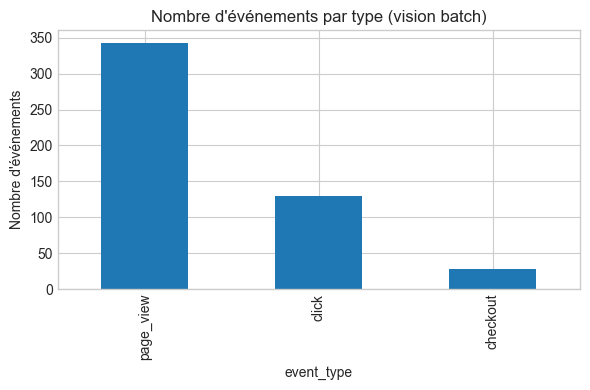

In [7]:
#Visualisation du nombre d'événements par type

plt.figure(figsize=(6, 4))
events_per_type.plot(kind="bar")
plt.title("Nombre d'événements par type (vision batch)")
plt.xlabel("event_type")
plt.ylabel("Nombre d'événements")
plt.tight_layout()
plt.show()


###TO DO 2 : Analyse batch

1. Interprétez le graphique :
   - quel type d’événement domine ?
   - est-ce cohérent avec les probabilités de simulation ?

2. Calculez le **nombre moyen d’événements par utilisateur**.
3. Expliquez pourquoi cette vision est utile mais insuffisante pour :
   - détecter une fraude,
   - recommander un produit en cours de navigation.


1. L'événement dominant est le page_view. Il est cohérent avec la probabilité de 0.7 que nous avons mise en place.
340 + 125 + 25 = 490
340 * 100 / 490 = 69.4%

2. 500/20=25 événement par utilisateur.
3. On ne peut pas voir ici si l'utilisateur a fait 100 clics sur 20h (utilisateur très actif) ou 100 clics en 3 min (cas de fraude)
Pour de la recommandation de produit, un utilisateur lambda peut exister entre 2 produits mais sans temps réel, on ne verra l'information que le lendemain ou plus tard, mais l'utilisateur sera déjà parti du site.


## 3. Vision "streaming naïve" : traitement au fil de l'eau

On va maintenant supposer que les événements arrivent **un par un**, dans un ordre donné,
et que l’on met à jour des compteurs en temps réel.

Pour l’instant, on ne modélise pas encore le désordre, juste l’idée de traiter "au fil de l’eau".


In [8]:
#Traitement streaming naïf

def streaming_counter(events_df):
    """
    Simule un traitement streaming très simple :
    - on parcourt les événements dans l'ordre donné par le DataFrame
    - on maintient un compteur du nombre d'événements par type
    
    Ici, on suppose que l'ordre du DataFrame = ordre d'arrivée.
    """
    counts = {"page_view": 0, "click": 0, "checkout": 0}
    history = []  # pour garder une trace de l'évolution des compteurs
    
    for _, row in events_df.iterrows():
        etype = row["event_type"]
        counts[etype] += 1
        
        # On enregistre un snapshot
        history.append(
            {
                "event_time": row["event_time"],
                "page_view": counts["page_view"],
                "click": counts["click"],
                "checkout": counts["checkout"],
            }
        )
    
    return pd.DataFrame(history)

df_streaming_counts = streaming_counter(df_events)
df_streaming_counts.head()


,event_time,page_view,click,checkout
0,2025-01-01 12:00:15,1,0,0
1,2025-01-01 12:00:21,2,0,0
2,2025-01-01 12:00:24,3,0,0
3,2025-01-01 12:00:24,4,0,0
4,2025-01-01 12:00:28,4,1,0


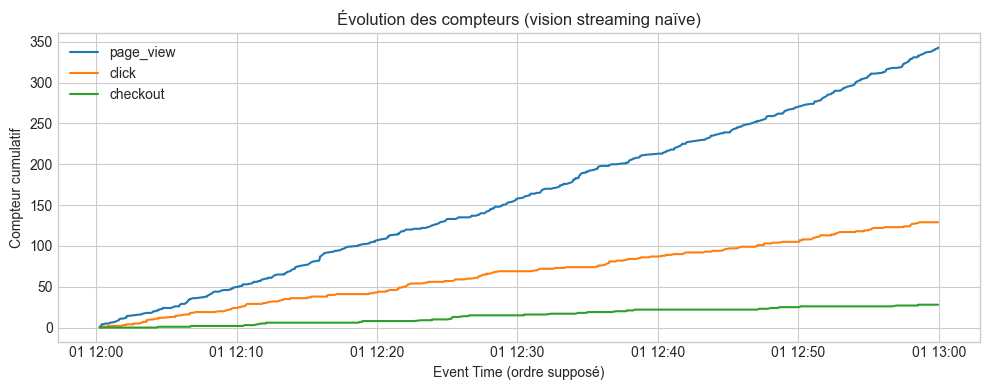

In [9]:
#Visualisation de l'évolution des compteurs

plt.figure(figsize=(10, 4))
for col in ["page_view", "click", "checkout"]:
    plt.plot(df_streaming_counts["event_time"], df_streaming_counts[col], label=col)

plt.legend()
plt.xlabel("Event Time (ordre supposé)")
plt.ylabel("Compteur cumulatif")
plt.title("Évolution des compteurs (vision streaming naïve)")
plt.tight_layout()
plt.show()


### TO DO 3 : Comparaison batch vs streaming naïf

1. Comparez le **résultat final** de `df_streaming_counts` avec `events_per_type` :
   - que remarquez-vous ?
   - pourquoi est-ce normal ?

2. Expliquez (en quelques lignes) en quoi la vision streaming est plus informative pour :
   - voir les pics d’activité,
   - suivre une campagne marketing en temps réel.


1. Les point d'arrivées des courbes à droite du graphique correspond exactement aux chiffres du tableau events_per_type.
C'est normal car le streaming et le batch comptent la même chose mais de manière différente.

2. Dans la vision du batch, on ne voit que le nombre d'événements types, alors qu'avec la vision du streaming, on peut voir si elles sont arrivées régulièrement ou non.
Pour une campagne marketing en temps réel, le batch est analysé après la campagne terminée, le streaming permet durant la phase de la campagne d'analyser immédiatement le suivi de celle-ci et de réagir si une anomalie est détectée.

## 4. Event Time vs Processing Time et désordre

Jusqu’ici, nous avons supposé que :

> ordre du DataFrame = ordre des événements dans le temps = ordre d’arrivée.

Dans la réalité :

- les événements peuvent arriver **en retard**,
- dans un **ordre différent** de l’Event Time.

Nous allons simuler :

- un `event_time` (moment réel),
- un `processing_time` (moment d’arrivée dans le système),
- un **délai aléatoire** entre les deux.


In [8]:
# Ajout d'un Processing Time avec désordre

def add_processing_time(events_df, max_delay_seconds=120):
    """
    Ajoute une colonne 'processing_time' en simulant un délai aléatoire
    entre l'Event Time et le Processing Time.
    
    - max_delay_seconds : délai maximum (en secondes)
    """
    df = events_df.copy()
    
    processing_times = []
    for _, row in df.iterrows():
        delay = np.random.randint(0, max_delay_seconds)
        p_time = row["event_time"] + timedelta(seconds=int(delay))
        processing_times.append(p_time)
    
    df["processing_time"] = processing_times
    
    # On crée une version triée par processing_time pour simuler l'ordre d'arrivée
    df_stream = df.sort_values("processing_time").reset_index(drop=True)
    return df_stream

df_stream_disordered = add_processing_time(df_events)
df_stream_disordered.head()


,event_id,user_id,event_type,event_time,processing_time
0,404,4,click,2025-01-01 12:00:28,2025-01-01 12:00:44
1,241,2,page_view,2025-01-01 12:00:42,2025-01-01 12:00:53
2,462,6,click,2025-01-01 12:00:53,2025-01-01 12:01:14
3,351,1,page_view,2025-01-01 12:01:02,2025-01-01 12:01:18
4,415,11,page_view,2025-01-01 12:00:24,2025-01-01 12:01:27


### TO DO 4 : Observer le désordre

1. Affichez les 10 premiers événements triés par `event_time` puis par `processing_time`.
2. Repérez des cas où :
   - un événement plus "tardif" en Event Time arrive plus tôt en Processing Time.
3. Discutez les conséquences si vous faites des statistiques sur :
   - Event Time,
   - Processing Time uniquement.


## 5. Agrégations par fenêtres temporelles

On veut maintenant calculer par exemple :

> nombre de clics par minute (en Event Time)

Puis comparer avec :

> nombre de clics par minute observés en Processing Time (avec désordre).

Objectif : montrer que les statistiques **métier** doivent être faites en Event Time.


In [10]:
#Préparation : arrondir les temps à la minute

def floor_to_minute(dt):
    """Ramène un datetime à la minute inférieure (secondes = 0)."""
    return dt.replace(second=0, microsecond=0)

df_stream_disordered["event_minute"] = df_stream_disordered["event_time"].apply(floor_to_minute)
df_stream_disordered["processing_minute"] = df_stream_disordered["processing_time"].apply(floor_to_minute)

df_stream_disordered.head()


,event_id,user_id,event_type,event_time,processing_time,event_minute,processing_minute
0,404,4,click,2025-01-01 12:00:28,2025-01-01 12:00:44,2025-01-01 12:00:00,2025-01-01 12:00:00
1,241,2,page_view,2025-01-01 12:00:42,2025-01-01 12:00:53,2025-01-01 12:00:00,2025-01-01 12:00:00
2,462,6,click,2025-01-01 12:00:53,2025-01-01 12:01:14,2025-01-01 12:00:00,2025-01-01 12:01:00
3,351,1,page_view,2025-01-01 12:01:02,2025-01-01 12:01:18,2025-01-01 12:01:00,2025-01-01 12:01:00
4,415,11,page_view,2025-01-01 12:00:24,2025-01-01 12:01:27,2025-01-01 12:00:00,2025-01-01 12:01:00


In [11]:
#Clics par minute en Event Time vs Processing Time

# Filtrage sur les "click"
df_clicks = df_stream_disordered[df_stream_disordered["event_type"] == "click"].copy()

# Agrégations
clicks_by_event_minute = df_clicks.groupby("event_minute")["event_id"].count().rename("clicks_event_time")
clicks_by_processing_minute = df_clicks.groupby("processing_minute")["event_id"].count().rename("clicks_processing_time")

# Fusion sur un index temporel "complet"
df_clicks_minute = pd.concat(
    [clicks_by_event_minute, clicks_by_processing_minute],
    axis=1
).fillna(0)

df_clicks_minute.head(10)


,clicks_event_time,clicks_processing_time
2025-01-01 12:00:00,2.0,1.0
2025-01-01 12:01:00,1.0,1.0
2025-01-01 12:02:00,2.0,1.0
2025-01-01 12:03:00,5.0,4.0
2025-01-01 12:04:00,2.0,3.0
2025-01-01 12:05:00,3.0,2.0
2025-01-01 12:06:00,3.0,3.0
2025-01-01 12:07:00,1.0,3.0
2025-01-01 12:08:00,1.0,1.0
2025-01-01 12:09:00,4.0,2.0


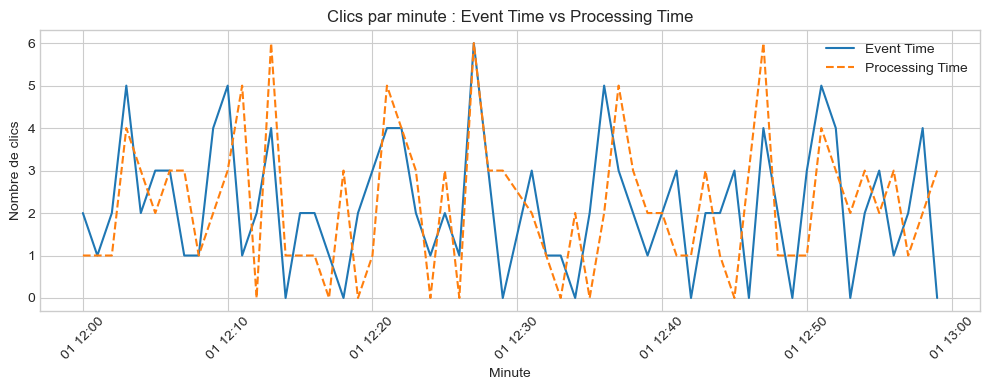

In [12]:
#Visualisation comparative

plt.figure(figsize=(10, 4))
plt.plot(df_clicks_minute.index, df_clicks_minute["clicks_event_time"], label="Event Time")
plt.plot(df_clicks_minute.index, df_clicks_minute["clicks_processing_time"], label="Processing Time", linestyle="--")

plt.legend()
plt.xlabel("Minute")
plt.ylabel("Nombre de clics")
plt.title("Clics par minute : Event Time vs Processing Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### TO DO 5 : Interprétation métier

1. Comparez visuellement les deux courbes :
   - sont-elles identiques ?
   - quelles différences observez-vous ?

2. Expliquez pourquoi, pour un rapport du type :
   > "Clics par minute pendant une campagne"
   
   il est **dangereux** de se baser uniquement sur le Processing Time.

3. Donnez un exemple où l'on pourrait tout de même s’autoriser à utiliser Processing Time
   (indice : monitoring purement technique).


## 6. Mini-modèle de log Kafka en Python

Nous allons implémenter un **jouet** inspiré de Kafka :

- Un `Topic` avec plusieurs `partitions`
- Chaque partition est un **log** ordonné de messages (offsets 0, 1, 2, …)
- Des `producers` qui écrivent dans une partition (choisie par `key`)
- Des `consumers` qui lisent et conservent leur dernier offset

Objectif : 
- ancrer les notions de **topic, partition, offset, consumer group** avec du code.


In [14]:
#Classe Partition (log simple)

class Partition:
    """
    Modélise une partition Kafka simplifiée :
    - une liste de messages
    - chaque message a un offset croissant
    """
    def __init__(self, name):
        self.name = name
        self.messages = []  # liste de (offset, key, value)
    
    def append(self, key, value):
        """
        Ajoute un message à la partition.
        Retourne l'offset assigné.
        """
        offset = len(self.messages)
        self.messages.append((offset, key, value))
        return offset
    
    def read_from(self, offset):
        """
        Renvoie tous les messages à partir d'un offset (inclus).
        """
        return [m for m in self.messages if m[0] >= offset]


In [16]:
#Classe Topic (avec plusieurs partitions)

class Topic:
    """
    Modélise un topic Kafka avec plusieurs partitions.
    
    - La partition est choisie en fonction de la key (hash modulo nb_partitions).
    """
    def __init__(self, name, num_partitions=3):
        self.name = name
        self.partitions = [Partition(f"{name}-part-{i}") for i in range(num_partitions)]
        self.num_partitions = num_partitions
    
    def _choose_partition(self, key):
        """
        Kafka réel utilise un hash.
        Ici, on simplifie : hash(key) modulo nb_partitions.
        """
        return hash(key) % self.num_partitions
    
    def append(self, key, value):
        """
        Ajoute un message dans la partition correspondant à la key.
        Retourne (partition_index, offset).
        """
        p_index = self._choose_partition(key)
        partition = self.partitions[p_index]
        offset = partition.append(key, value)
        return p_index, offset


In [17]:
#Classe Consumer

class Consumer:
    """
    Consumer simplifié qui lit depuis un topic :
    - garde en mémoire un offset par partition
    """
    def __init__(self, name, topic: Topic):
        self.name = name
        self.topic = topic
        # Offset initial : 0 dans chaque partition
        self.offsets = {i: 0 for i in range(topic.num_partitions)}
    
    def poll(self):
        """
        Lit les messages à partir des offsets courants,
        met à jour les offsets.
        Retourne la liste de (partition_index, offset, key, value).
        """
        records = []
        for p_index, partition in enumerate(self.topic.partitions):
            start_offset = self.offsets[p_index]
            new_messages = partition.read_from(start_offset)
            
            if new_messages:
                for (off, key, value) in new_messages:
                    records.append((p_index, off, key, value))
                
                # On avance l'offset de cette partition
                last_offset = new_messages[-1][0]
                self.offsets[p_index] = last_offset + 1
        
        return records


In [18]:
#Démonstration : écrire et lire dans le log

# Création d'un topic
topic_payments = Topic("paiements", num_partitions=3)

# Simulons quelques paiements
payments = [
    {"card_id": "C1", "amount": 50},
    {"card_id": "C2", "amount": 120},
    {"card_id": "C3", "amount": 200},
    {"card_id": "C1", "amount": 80},
]

# Producer "simplifié" : on se contente d'appeler topic.append
for pay in payments:
    key = pay["card_id"]
    value = pay
    p_idx, off = topic_payments.append(key, value)
    print(f"Message écrit sur partition {p_idx}, offset {off}, value={value}")


Message écrit sur partition 0, offset 0, value={'card_id': 'C1', 'amount': 50}
Message écrit sur partition 0, offset 1, value={'card_id': 'C2', 'amount': 120}
Message écrit sur partition 0, offset 2, value={'card_id': 'C3', 'amount': 200}
Message écrit sur partition 0, offset 3, value={'card_id': 'C1', 'amount': 80}


In [19]:
#Consumer qui lit depuis le topic

consumer_A = Consumer("consumer_A", topic_payments)

records = consumer_A.poll()
for rec in records:
    p_index, off, key, value = rec
    print(f"[Consumer A] Partition={p_index}, Offset={off}, key={key}, value={value}")

print("\nOffsets internes du consumer A :", consumer_A.offsets)


[Consumer A] Partition=0, Offset=0, key=C1, value={'card_id': 'C1', 'amount': 50}
[Consumer A] Partition=0, Offset=1, key=C2, value={'card_id': 'C2', 'amount': 120}
[Consumer A] Partition=0, Offset=2, key=C3, value={'card_id': 'C3', 'amount': 200}
[Consumer A] Partition=0, Offset=3, key=C1, value={'card_id': 'C1', 'amount': 80}

Offsets internes du consumer A : {0: 4, 1: 0, 2: 0}


### TO DO 6 : Consumer group simplifié

1. Créez un second consumer `consumer_B` sur le même topic.
2. Ajoutez de nouveaux paiements dans le topic.
3. Simulez un **consumer group** "à la main" :
   - vous décidez que `consumer_A` lit certaines partitions et `consumer_B` les autres
     (par exemple A lit partitions 0 et 1, B lit partition 2).
4. Observez comment cela permet de paralléliser la consommation.

*(C’est une version simplifiée du fonctionnement réel des consumer groups Kafka.)*


## 7. Garanties de livraison : mini-expériences

Rappel du cours :

- **At-most-once** : jamais doublé, parfois perdu.
- **At-least-once** : jamais perdu, parfois doublé.
- **Exactly-once** : ni perdu ni doublé (nécessite coordination fine).

On va simuler une version très simplifiée avec Python :

- une fonction qui "envoie" des messages avec une probabilité de perte,
- une autre qui "réessaye" automatiquement (risque de doublons).


In [21]:
#Simulation at-most-once

def send_at_most_once(messages, loss_prob=0.2):
    """
    Envoie des messages avec une certaine probabilité de perte.
    - Pas de retry.
    - Chaque message est envoyé au plus une fois.
    """
    delivered = []
    for msg in messages:
        if np.random.rand() > loss_prob:
            delivered.append(msg)
    return delivered

messages = list(range(20))
delivered_at_most_once = send_at_most_once(messages, loss_prob=0.3)

print("Messages initiaux :", messages)
print("Messages reçus (at-most-once) :", delivered_at_most_once)
print("Nombre perdus :", len(messages) - len(delivered_at_most_once))


Messages initiaux : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Messages reçus (at-most-once) : [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 18, 19]
Nombre perdus : 5


In [24]:
#Simulation at-least-once

def send_at_least_once(messages, loss_prob=0.2):
    """
    Envoie des messages avec retry jusqu'à ce qu'ils soient "livrés".
    - On simule des tentatives successives.
    - On garde TOUTES les livraisons pour visualiser les doublons.
    """
    delivered = []
    for msg in messages:
        delivered_once = False
        attempts = 0
        while not delivered_once and attempts < 10:
            attempts += 1
            if np.random.rand() > loss_prob:
                # livré !
                delivered.append(msg)
                delivered_once = True
            else:
                # échec, on retente
                delivered.append(("RETRY_FAIL", msg))
    return delivered

delivered_at_least_once = send_at_least_once(messages, loss_prob=0.3)

print("Extrait des livraisons (at-least-once) :")
print(delivered_at_least_once[:30])


Extrait des livraisons (at-least-once) :
[0, 1, 2, 3, 4, 5, ('RETRY_FAIL', 6), ('RETRY_FAIL', 6), 6, ('RETRY_FAIL', 7), 7, 8, 9, 10, 11, 12, 13, 14, 15, ('RETRY_FAIL', 16), 16, 17, 18, ('RETRY_FAIL', 19), 19]


### TO DO 7 : Analyse des garanties

1. Dans le cas **at-most-once** :
   - calculez le pourcentage de messages perdus sur plusieurs simulations.
2. Dans le cas **at-least-once** :
   - repérez les doublons (comment ?),
   - expliquez pourquoi certaines applications (ex : comptabilité) ne peuvent pas l’accepter.
3. Proposez (en quelques lignes) un **mécanisme applicatif** pour éliminer les doublons
   (indice : utiliser un identifiant unique de message).


# 8. Mini-projets guidés

Les mini-projets suivants réutilisent **toutes les notions** vues dans la séance :

- flux d’événements
- batch vs streaming
- Event Time / Processing Time
- latence et désordre
- pipeline temps réel
- inspiration Kafka (log, offsets, consumer groups)
- garanties de livraison

Chaque mini-projet est guidé avec du code commenté et des `TODO`.


## Mini-projet 1 : Monitoring temps réel d’un capteur de température (IoT)

**Contexte :**

- Un capteur envoie une mesure de température toutes les 2 secondes.
- On veut :
  - surveiller un seuil critique (90°C),
  - détecter des **pentes anormales** (augmentation trop rapide),
  - comparer une détection **batch** vs **streaming**.

**Objectifs  :**

- Manipuler un flux d’événements de type capteur.
- Implémenter une logique de détection temps réel simple.
- Visualiser Event Time vs Processing Time.


In [25]:
#Simulation d'un flux de température

def simulate_temperature_stream(
    n_events=300,
    base_temp=70.0,
    noise_std=1.0,
    spike_prob=0.05,
    spike_magnitude=15.0,
    start_time=datetime(2025, 1, 1, 9, 0, 0)
):
    """
    Simule une série de températures :
    - température de base autour de 'base_temp'
    - bruit gaussien
    - de temps en temps, un "spike" (hausse brutale) est ajouté
    """
    events = []
    current_time = start_time
    
    temp = base_temp
    
    for i in range(n_events):
        # bruit aléatoire
        temp = temp + np.random.normal(0, noise_std)
        
        # parfois, spike (ex: problème sur la machine)
        if np.random.rand() < spike_prob:
            temp += spike_magnitude
        
        events.append(
            {
                "event_id": i,
                "sensor_id": 1,
                "event_type": "temperature",
                "event_time": current_time,
                "value": temp,
            }
        )
        
        # prochain événement 2 secondes plus tard en Event Time
        current_time += timedelta(seconds=2)
    
    return pd.DataFrame(events)

df_temp = simulate_temperature_stream()
df_temp.head()


,event_id,sensor_id,event_type,event_time,value
0,0,1,temperature,2025-01-01 09:00:00,69.533185
1,1,1,temperature,2025-01-01 09:00:02,69.105860
2,2,1,temperature,2025-01-01 09:00:04,69.628279
3,3,1,temperature,2025-01-01 09:00:06,69.835123
4,4,1,temperature,2025-01-01 09:00:08,70.089372


Nombre de mesures au-dessus du seuil (batch) : 268


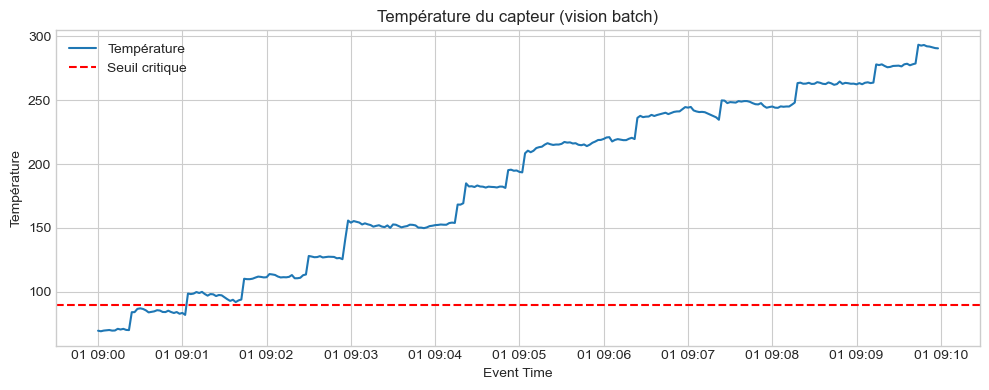

In [26]:
#Détection batch des dépassements de seuil

SEUIL = 90.0

# Vision batch : on parcourt l'historique complet
df_temp["is_above_seuil"] = df_temp["value"] > SEUIL

print("Nombre de mesures au-dessus du seuil (batch) :",
      df_temp["is_above_seuil"].sum())

plt.figure(figsize=(10, 4))
plt.plot(df_temp["event_time"], df_temp["value"], label="Température")
plt.axhline(SEUIL, color="red", linestyle="--", label="Seuil critique")
plt.xlabel("Event Time")
plt.ylabel("Température")
plt.title("Température du capteur (vision batch)")
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
#Détection streaming (online) avec alertes

def streaming_temperature_alerts(df, seuil=90.0, slope_threshold=10.0):
    """
    Parcours streaming :
    - si la température dépasse 'seuil', on émet une alerte
    - si la température augmente de plus de 'slope_threshold' en 30 secondes, alerte
    
    On suppose que df est trié par event_time.
    """
    alerts = []
    prev_value = None
    prev_time = None
    
    for _, row in df.iterrows():
        temp = row["value"]
        t = row["event_time"]
        
        # Alerte seuil
        if temp > seuil:
            alerts.append((t, "SEUIL", temp))
        
        # Alerte pente (si on a une mesure précédente)
        if prev_value is not None:
            dt_seconds = (t - prev_time).total_seconds()
            # Pour simplifier : on regarde la variation absolue en 30s (15 mesures)
            # (vous pouvez raffiner)
            delta = temp - prev_value
            # Rapporter la pente sur 30s
            if dt_seconds > 0:
                slope_30s = delta * (30.0 / dt_seconds)
                if slope_30s > slope_threshold:
                    alerts.append((t, "PENTE", temp))
        
        prev_value = temp
        prev_time = t
    
    return alerts

alerts = streaming_temperature_alerts(df_temp)
alerts[:10]


[(Timestamp('2025-01-01 09:00:14'), 'PENTE', 71.01579673456644),
 (Timestamp('2025-01-01 09:00:24'), 'PENTE', 84.0142836429578),
 (Timestamp('2025-01-01 09:00:28'), 'PENTE', 86.62880334489095),
 (Timestamp('2025-01-01 09:00:42'), 'PENTE', 85.58217181322094),
 (Timestamp('2025-01-01 09:00:50'), 'PENTE', 85.22287909292643),
 (Timestamp('2025-01-01 09:00:56'), 'PENTE', 84.1536748192888),
 (Timestamp('2025-01-01 09:01:00'), 'PENTE', 83.46849077610223),
 (Timestamp('2025-01-01 09:01:04'), 'SEUIL', 98.62750587629061),
 (Timestamp('2025-01-01 09:01:04'), 'PENTE', 98.62750587629061),
 (Timestamp('2025-01-01 09:01:06'), 'SEUIL', 98.21498122377346)]

### TO DO 

1. Affichez toutes les alertes et discutez :
   - combien sont liées au seuil ?
   - combien à la pente ?

2. Introduisez un **Processing Time** artificiel (avec délai aléatoire) comme plus haut :
   - comparez la détection basée sur Event Time vs Processing Time.

3. Expliquez dans quels cas un léger retard (Processing Time) est acceptable
   et dans quels cas il ne l’est pas (sécurité, santé, etc.).


## Mini-projet 2 : Flux de transactions et détection de fraude simplifiée

**Contexte :**

- On reçoit un flux de transactions par carte bancaire.
- On veut **étiqueter en temps réel** des transactions suspectes selon des règles simples :
  - montant > 1000,
  - plus de 5 transactions en moins de 10 minutes pour une même carte,
  - pays inhabituel (optionnel : champs supplémentaires).

**Objectifs :**

- manipuler un flux de transactions comme des événements,
- maintenir un **état par carte** dans une logique streaming,
- comparer avec une vision purement batch.


In [28]:
#Simulation de transactions

def simulate_transactions(
    n_trans=300,
    start_time=datetime(2025, 1, 1, 10, 0, 0),
    max_amount=1500
):
    """
    Simule un flux de transactions par cartes :
    - card_id : C1,...,C10
    - amount : montant aléatoire
    """
    events = []
    current_time = start_time
    
    for i in range(n_trans):
        card_id = f"C{np.random.randint(1, 11)}"  # 10 cartes
        amount = np.round(np.random.exponential(scale=100), 2)
        
        # De temps en temps, grosse transaction
        if np.random.rand() < 0.05:
            amount += np.random.uniform(1000, max_amount)
        
        events.append(
            {
                "event_id": i,
                "card_id": card_id,
                "amount": amount,
                "event_time": current_time,
            }
        )
        
        # Next transaction : délai aléatoire entre 5 et 90 sec
        current_time += timedelta(seconds=int(np.random.randint(5, 90)))
    
    df = pd.DataFrame(events)
    return df.sort_values("event_time").reset_index(drop=True)

df_trans = simulate_transactions()
df_trans.head()


,event_id,card_id,amount,event_time
0,0,C4,278.55,2025-01-01 10:00:00
1,1,C9,155.33,2025-01-01 10:00:43
2,2,C3,237.73,2025-01-01 10:02:09
3,3,C2,59.25,2025-01-01 10:02:36
4,4,C3,53.23,2025-01-01 10:03:52


In [29]:
#Détection batch des montants "élevés"

HIGH_AMOUNT = 1000

df_trans["is_high_amount"] = df_trans["amount"] > HIGH_AMOUNT
df_trans["is_high_amount"].sum(), df_trans["amount"].describe()


(np.int64(16),
 count     300.000000
 mean      164.294337
 std       300.119633
 min         0.380000
 25%        37.195000
 50%        76.765000
 75%       147.102500
 max      1880.403962
 Name: amount, dtype: float64)

In [30]:
#Détection streaming avec état par carte

from collections import deque, defaultdict

def streaming_fraud_detection(df, high_amount=1000, window_minutes=10, max_tx_in_window=5):
    """
    Détection très simplifiée :
    - alerte si amount > high_amount
    - alerte si plus de max_tx_in_window transactions pour une carte
      dans une fenêtre de window_minutes (en Event Time).
      
    On maintient pour chaque carte une deque des timestamps récents.
    """
    alerts = []
    history_per_card = defaultdict(deque)
    window = timedelta(minutes=window_minutes)
    
    for _, row in df.iterrows():
        card = row["card_id"]
        amount = row["amount"]
        t = row["event_time"]
        
        # 1. Alerte montant élevé
        if amount > high_amount:
            alerts.append((t, card, "HIGH_AMOUNT", amount))
        
        # 2. Fenêtre glissante sur l'historique de la carte
        history = history_per_card[card]
        history.append(t)
        
        # On enlève de la deque les timestamps trop anciens
        while history and (t - history[0]) > window:
            history.popleft()
        
        if len(history) > max_tx_in_window:
            alerts.append((t, card, "FREQUENT_TX", len(history)))
    
    return alerts

alerts_fraud = streaming_fraud_detection(df_trans)
alerts_fraud[:10]


[(Timestamp('2025-01-01 10:10:08'), 'C1', 'HIGH_AMOUNT', 1262.073982732253),
 (Timestamp('2025-01-01 10:24:01'), 'C1', 'HIGH_AMOUNT', 1078.7428770653457),
 (Timestamp('2025-01-01 10:31:48'), 'C8', 'HIGH_AMOUNT', 1557.4760623657971),
 (Timestamp('2025-01-01 10:38:24'), 'C7', 'HIGH_AMOUNT', 1147.5916475618728),
 (Timestamp('2025-01-01 10:42:52'), 'C10', 'HIGH_AMOUNT', 1242.6971126726457),
 (Timestamp('2025-01-01 10:50:34'), 'C4', 'FREQUENT_TX', 6),
 (Timestamp('2025-01-01 10:51:00'), 'C4', 'FREQUENT_TX', 7),
 (Timestamp('2025-01-01 10:54:54'), 'C4', 'FREQUENT_TX', 6),
 (Timestamp('2025-01-01 11:38:52'), 'C4', 'HIGH_AMOUNT', 1342.3533302754608),
 (Timestamp('2025-01-01 11:46:17'), 'C5', 'HIGH_AMOUNT', 1177.5243053902823)]

### TO DO 

1. Comptez le nombre d’alertes par type (`HIGH_AMOUNT`, `FREQUENT_TX`).
2. Visualisez, pour une carte donnée, la timeline de ses transactions et de ses alertes.
3. Introduisez un `processing_time` avec désordre :
   - observez si certaines alertes sont déclenchées plus tard en Processing Time
     qu’en Event Time.
4. Discutez le compromis :
   - faux positifs / faux négatifs
   - latence d’alerte acceptable.


## Mini-projet 3 : Jouet "Kafka + Streaming" pour des clics e-commerce

**Contexte :**

- Un topic `clicks` contient des événements de clic.
- On veut consommer ce flux en temps réel pour :
  - compter le nombre de clics par produit,
  - maintenir un **top-N produits** les plus cliqués.

**Objectifs :**

- réutiliser le mini-modèle de `Topic` / `Partition` / `Consumer`,
- simuler un **producer** qui envoie les clics dans le topic,
- implémenter un consumer qui maintient un état (`state`) : compteur par produit.


In [32]:
#Simulation de clics produits

def simulate_product_clicks(n_events=200, n_products=20):
    """
    Génère une liste d'événements clics produits.
    Chaque événement est un dict avec :
    - user_id
    - product_id
    """
    events = []
    for i in range(n_events):
        user_id = np.random.randint(1, 51)  # 50 utilisateurs
        product_id = np.random.randint(1, n_products + 1)
        events.append(
            {
                "user_id": user_id,
                "product_id": product_id,
            }
        )
    return events

click_events = simulate_product_clicks()
click_events[:5]


[{'user_id': 34, 'product_id': 16},
 {'user_id': 47, 'product_id': 13},
 {'user_id': 48, 'product_id': 17},
 {'user_id': 29, 'product_id': 7},
 {'user_id': 24, 'product_id': 17}]

In [34]:
#Topic "clicks" et producer

topic_clicks = Topic("clicks", num_partitions=3)

def producer_send_clicks(topic: Topic, events):
    """
    Producer simplifié :
    - pour chaque clic, on utilise product_id comme key
    - on envoie dans le topic
    """
    for e in events:
        key = e["product_id"]
        value = e
        p_idx, off = topic.append(key, value)
        # En pratique on ne print pas, mais ici c'est pédagogique
        # print(f"Produced click product={key} on partition={p_idx}, offset={off}")

producer_send_clicks(topic_clicks, click_events)


In [35]:
#Consumer qui maintient un compteur par produit

class ClicksConsumer(Consumer):
    """
    Consumer spécialisé :
    - hérite de Consumer
    - maintient un état "nombre de clics par produit"
    """
    def __init__(self, name, topic: Topic):
        super().__init__(name, topic)
        self.counts_per_product = {}
    
    def poll_and_update_state(self):
        """
        Poll les nouveaux messages et met à jour le state.
        """
        records = super().poll()
        for p_index, off, key, value in records:
            product_id = value["product_id"]
            self.counts_per_product[product_id] = self.counts_per_product.get(product_id, 0) + 1
        
        return records

consumer_clicks = ClicksConsumer("consumer_clicks", topic_clicks)
records = consumer_clicks.poll_and_update_state()

print("Nombre de messages lus :", len(records))
print("État interne (clics par produit) :", consumer_clicks.counts_per_product)


Nombre de messages lus : 200
État interne (clics par produit) : {3: 11, 9: 6, 6: 10, 15: 7, 12: 7, 18: 10, 16: 9, 13: 12, 7: 10, 19: 12, 4: 10, 10: 10, 1: 5, 17: 14, 11: 14, 2: 11, 14: 10, 8: 14, 20: 12, 5: 6}


In [36]:
#Top-n produits les plus cliqués

def top_n_products(counts_dict, n=5):
    """
    Retourne la liste des n produits les plus cliqués,
    ordonnés par nombre de clics décroissant.
    """
    items = list(counts_dict.items())  # (product_id, count)
    items_sorted = sorted(items, key=lambda x: x[1], reverse=True)
    return items_sorted[:n]

top5 = top_n_products(consumer_clicks.counts_per_product, n=5)
top5


[(17, 14), (11, 14), (8, 14), (13, 12), (19, 12)]

### TO DO 

1. Simulez plusieurs "vagues" de clics :
   - envoyez un premier lot, consommez, regardez le top-5,
   - envoyez un second lot, consommez, observez comment le top-5 évolue.

2. Modifiez la clé de partitionnement :
   - au lieu de `product_id`, utilisez `user_id`.
   - observez l’impact sur la répartition des offsets (explorer `partition.messages`).

3. Discutez :
   - pourquoi l’ordre est garanti **à l’intérieur d’une partition** mais pas entre partitions ?
   - dans quel cas métier cette propriété est suffisante ?


## Conclusion du TP

Dans ce TP, vous avez :

- manipulé des **flux d’événements** (web, IoT, transactions, clics),
- comparé des approches **batch** vs **streaming**,
- étudié le **désordre** entre Event Time et Processing Time,
- construit des agrégations par **fenêtres temporelles**,
- implémenté un mini-modèle de **Kafka** en Python (topic, partitions, offsets, consumers),
- exploré les garanties de livraison (at-most-once, at-least-once),
- réalisé 3 **mini-projets** appliqués :
  - monitoring de température (IoT),
  - détection de fraude simplifiée,
  - top-N produits cliqués via un flux à la Kafka.

Ce TP couvre ainsi l’ensemble des notions de la **séance 1** et prépare la suite du cours
(ingestion réelle, frameworks de streaming, intégration avec de vrais brokers de messages).
